# Exploration: Daily Series
**DAILY MISSION DATA**

---

**Zweck:** Die offizielle Tagesreihe der Stadt durchleuchten und gegen die Einzeleinsätze prüfen.  
**Input:** `stg_daily_missions` und `stg_missions` aus `data/berlin_emergency.duckdb`.  
**Output:** Fazit zu Inhalt, Nutzen und Grenzen; Klärung der RD-Kategorien und der Abweichung zu den Einsätzen.

## Setup

In [1]:
from berlin_emergency_response.notebook import *
import duckdb
from wgnd.viz import bar, line

setup_plotting()
con = duckdb.connect(str(PATHS["db"]), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

✓  wgnd theme activated (matplotlib · seaborn)

## Structure

### Rows and Coverage

In [2]:
df_daily = q('select * from stg_daily_missions order by mission_date')
df_cov = q("""
    with span as (select unnest(generate_series(min(mission_date), max(mission_date), interval 1 day))::date as day from stg_daily_missions)
    select (select count(*) from stg_daily_missions) as rows_in_table,
           count(*) as days_in_span,
           count(*) filter (where d.mission_date is null) as missing_days,
           min(span.day) as first_day, max(span.day) as last_day
    from span left join stg_daily_missions d on d.mission_date = span.day
""")
show_df(df_cov)

,rows_in_table,days_in_span,missing_days,first_day,last_day
0,3195,3202,7,2018-01-01 00:00:00,2026-10-07 00:00:00


### Missing Days

In [3]:
df_gap = q("""
    with span as (select unnest(generate_series(min(mission_date), max(mission_date), interval 1 day))::date as day from stg_daily_missions)
    select span.day as missing_day, dayname(span.day) as weekday
    from span left join stg_daily_missions d on d.mission_date = span.day
    where d.mission_date is null order by 1
""")
df_gap_detail = q("select mission_date, count(*) as n_detail from stg_missions group by 1")
show_df(df_gap.merge(df_gap_detail, left_on='missing_day', right_on='mission_date', how='left').drop(columns='mission_date'))

,missing_day,weekday,n_detail
0,2026-01-23 00:00:00,Friday,1595
1,2026-04-20 00:00:00,Monday,1518
2,2026-06-19 00:00:00,Friday,1821
3,2026-06-21 00:00:00,Sunday,1810
4,2026-07-13 00:00:00,Monday,1619
5,2026-07-23 00:00:00,Thursday,1492
6,2026-08-24 00:00:00,Monday,1557


### Columns

Die Spalten gliedern sich in Einsatzzahlen (`mission_count_*`), Rettungsdienst-Notfallkategorien (`mission_count_rd1` bis `rd5`) und Antwortzeit-Statistiken (`response_time_*`, je Mittelwert, Median, Standardabweichung).


───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,3195,
1,columns,31,
2,duplicates,0,0.0%
3,empty rows (all NaN),0,0.0%
4,empty cols (all NaN),0,0.0%



───  DTYPES  ─────────────────────────────────────────────────


,column,dtype,missing_cnt,missing_pct,unique,unique_pct
0,mission_date,datetime64[us],0,0.00%,3195,100.00%
1,mission_count_all,int32,0,0.00%,655,20.50%
2,mission_count_ems,int32,0,0.00%,596,18.65%
3,mission_count_ems_critical,int32,0,0.00%,755,23.63%
4,mission_count_ems_critical_cpr,int32,0,0.00%,42,1.31%
5,mission_count_fire,int32,0,0.00%,104,3.26%
6,mission_count_technical_rescue,int32,0,0.00%,136,4.26%
7,mission_count_rd1,int32,0,0.00%,97,3.04%
8,mission_count_rd2,int32,0,0.00%,514,16.09%
9,mission_count_rd3,int32,0,0.00%,492,15.40%



───  MISSING VALUES  ─────────────────────────────────────────


,column,missing_cnt,missing_pct
0,response_time_ems_critical_cpr_std,3,0.09%


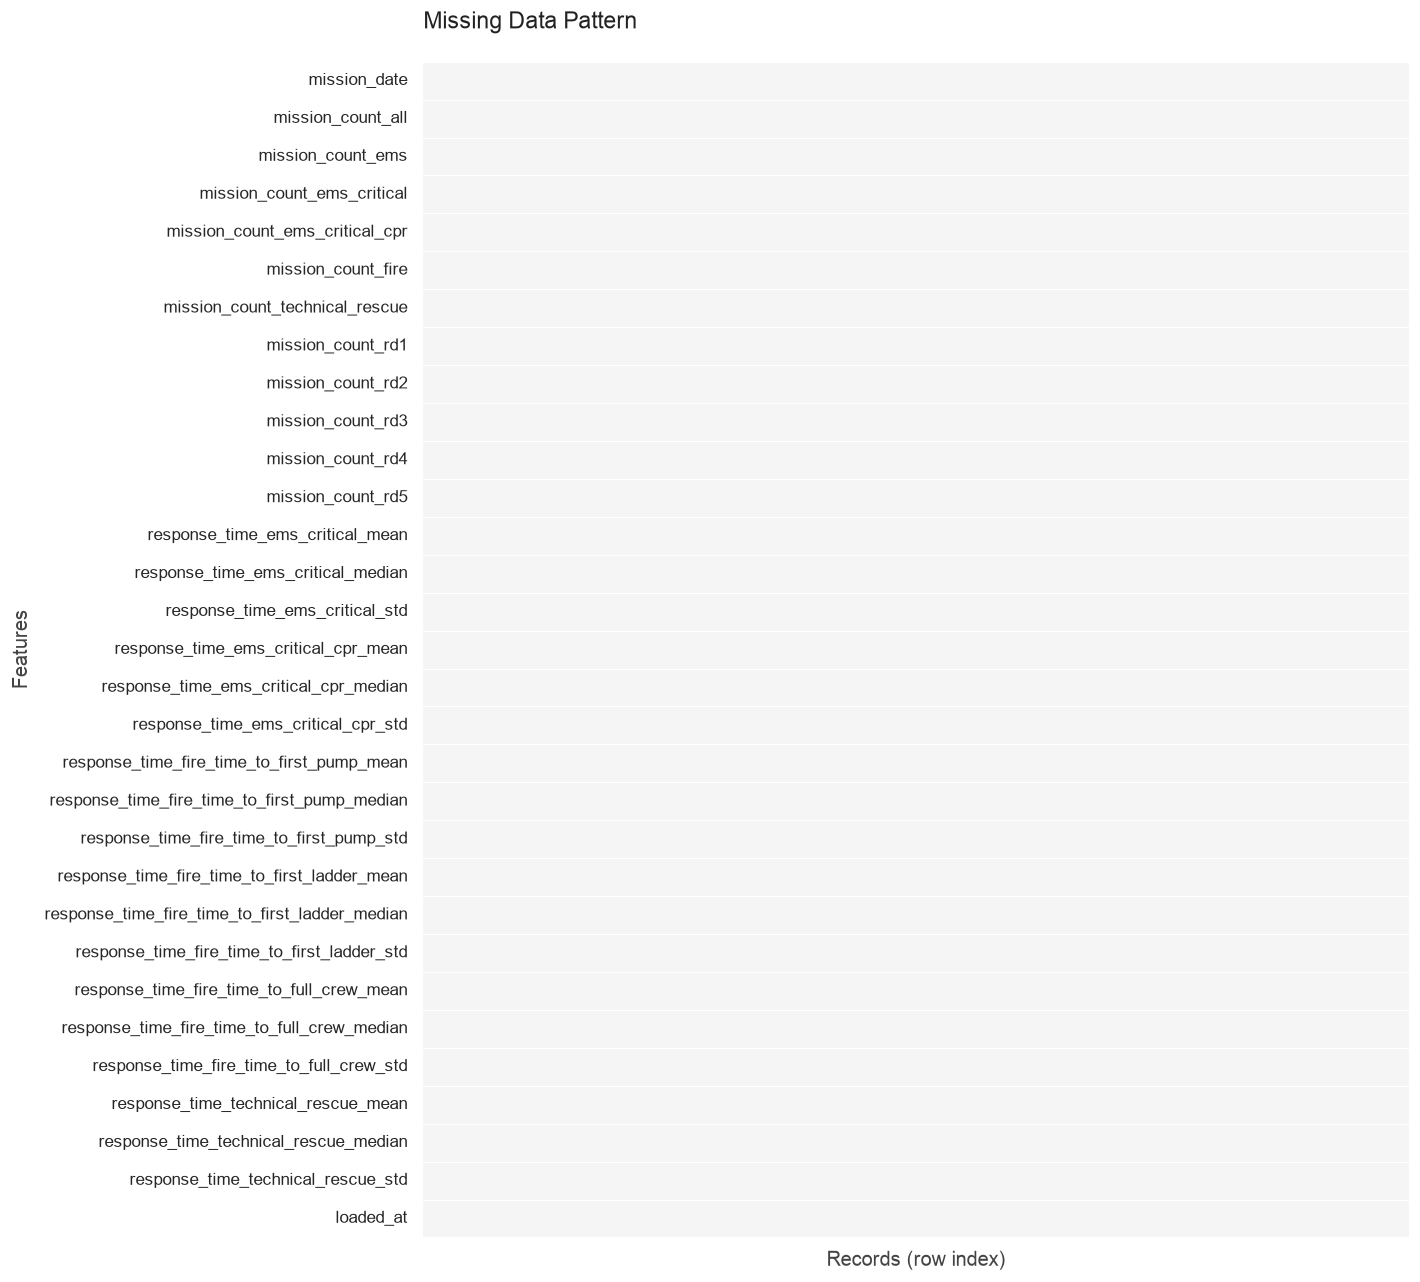

In [4]:
inspect(df_daily, sections=['dimensions', 'dtypes', 'missing'])

## Volumes

### Per Year

In [5]:
df_year = q("""
    select year(mission_date) as year, count(*) as days, sum(mission_count_all) as missions, sum(mission_count_ems) as ems,
           sum(mission_count_fire) as fire, sum(mission_count_technical_rescue) as technical_rescue,
           round(avg(mission_count_all), 0) as avg_per_day
    from stg_daily_missions group by 1 order by 1
""")
show_df(df_year)

,year,days,missions,ems,fire,technical_rescue,avg_per_day
0,2018,365,465755.00,433303.00,15055.00,16633.00,1276.00
1,2019,365,474736.00,433504.00,15861.00,17900.00,1301.00
2,2020,366,468682.00,418403.00,15878.00,15705.00,1281.00
3,2021,365,492231.00,440587.00,16405.00,18371.00,1349.00
4,2022,365,528921.00,473888.00,18714.00,21383.00,1449.00
5,2023,365,514830.00,462936.00,18827.00,19112.00,1410.00
6,2024,366,534452.00,481462.00,20652.00,19045.00,1460.00
7,2025,365,558721.00,503371.00,21630.00,20698.00,1531.00
8,2026,273,429119.00,386933.00,17082.00,15395.00,1572.00


### Seasonality and Weekday

,month,avg_missions_per_day,avg_daily_median_s
0,1,1364.00,590.00
1,2,1369.00,596.00
2,3,1356.00,590.00
3,4,1331.00,583.00
4,5,1375.00,582.00
5,6,1459.00,589.00
6,7,1393.00,585.00
7,8,1388.00,590.00
8,9,1389.00,596.00
9,10,1375.00,600.00


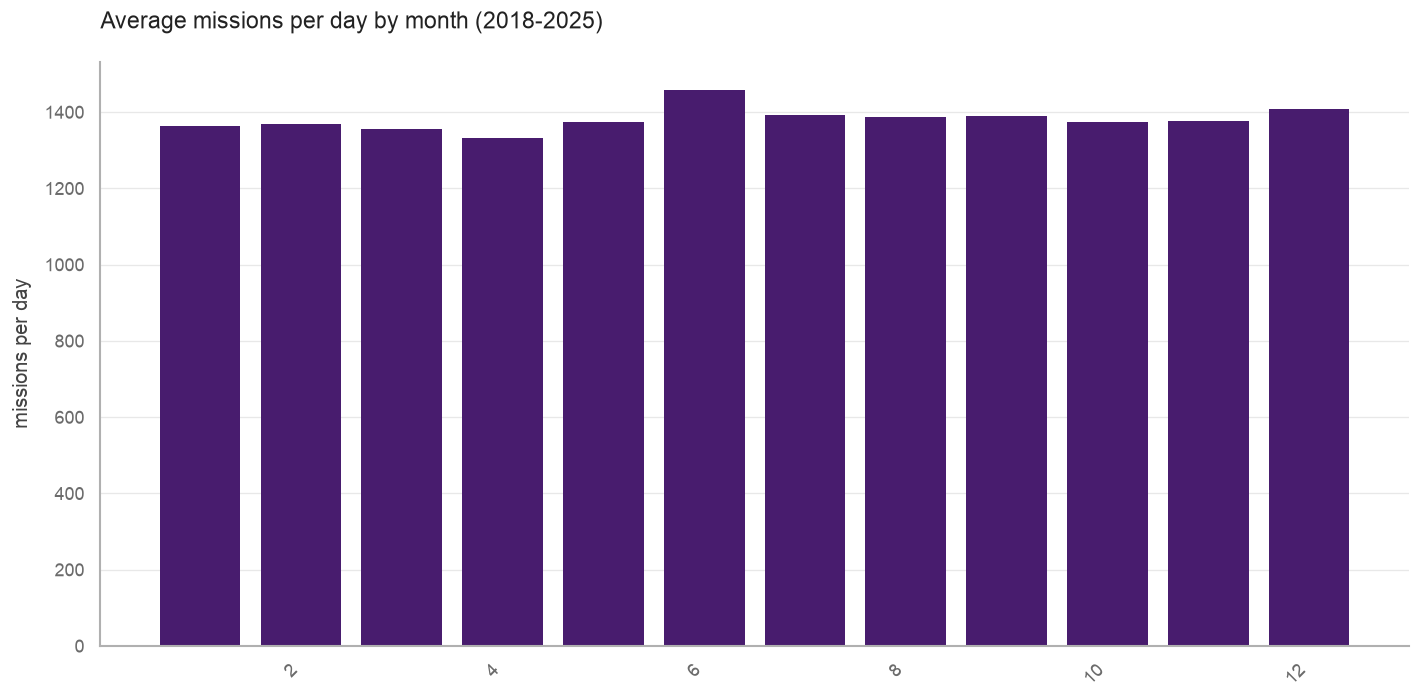

In [6]:
df_month = q("""
    select month(mission_date) as month, round(avg(mission_count_all), 0) as avg_missions_per_day,
           round(avg(response_time_ems_critical_median), 0) as avg_daily_median_s
    from stg_daily_missions where year(mission_date) between 2018 and 2025 group by 1 order by 1
""")
show_df(df_month)
fig, ax = bar(df_month, x='month', y='avg_missions_per_day', title='Average missions per day by month (2018-2025)', ylabel='missions per day')

In [7]:
df_wd = q("""
    select dayname(mission_date) as weekday, isodow(mission_date) as dow, round(avg(mission_count_all), 0) as avg_missions_per_day,
           round(avg(response_time_ems_critical_median), 0) as avg_daily_median_s
    from stg_daily_missions where year(mission_date) between 2018 and 2025 group by 1, 2 order by 2
""")
show_df(df_wd.drop(columns='dow'))

,weekday,avg_missions_per_day,avg_daily_median_s
0,Monday,1414.00,598.00
1,Tuesday,1376.00,594.00
2,Wednesday,1386.00,596.00
3,Thursday,1394.00,598.00
4,Friday,1404.00,598.00
5,Saturday,1380.00,589.00
6,Sunday,1320.00,579.00


### Monthly Trend

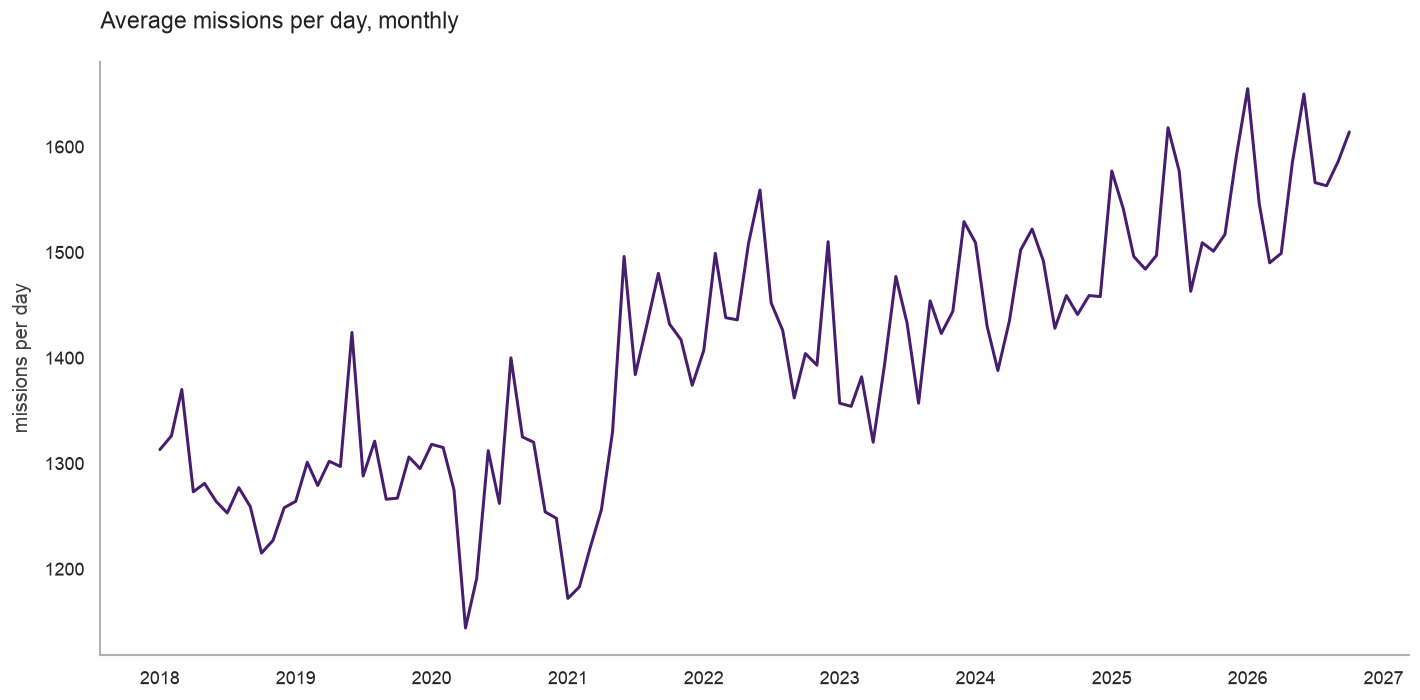

In [8]:
df_trend = q("""
    select date_trunc('month', mission_date)::date as month, round(avg(mission_count_all), 0) as avg_missions_per_day
    from stg_daily_missions group by 1 order by 1
""")
fig, ax = line(df_trend, x='month', y='avg_missions_per_day', title='Average missions per day, monthly', ylabel='missions per day')

## Emergency Categories RD1 to RD5

Laut Feldbeschreibung der BF sind `mission_count_rd1` bis `rd5` Rettungsdiensteinsätze nach Notfallkategorie RD1 bis RD5; RD1 und RD2 sind als *critical* gekennzeichnet. Hypothese (Vermutung): `mission_count_ems_critical` entspricht RD1 plus RD2. Wir prüfen es.

In [9]:
df_rd = q("""
    select year(mission_date) as year, sum(mission_count_ems) as ems, sum(mission_count_ems_critical) as critical,
           sum(mission_count_rd1) as rd1, sum(mission_count_rd2) as rd2, sum(mission_count_rd3) as rd3,
           sum(mission_count_rd4) as rd4, sum(mission_count_rd5) as rd5
    from stg_daily_missions group by 1 order by 1
""")
df_rd['rd1_to_rd5'] = df_rd[['rd1', 'rd2', 'rd3', 'rd4', 'rd5']].sum(axis=1)
df_rd['rd1_rd2'] = df_rd['rd1'] + df_rd['rd2']
df_rd['critical_vs_rd1_rd2_pct'] = ((df_rd['critical'] / df_rd['rd1_rd2'] - 1) * 100).round(1)
df_rd['ems_vs_rd1_to_rd5_pct'] = ((df_rd['ems'] / df_rd['rd1_to_rd5'] - 1) * 100).round(1)
show_df(df_rd)

,year,ems,critical,rd1,rd2,rd3,rd4,rd5,rd1_to_rd5,rd1_rd2,critical_vs_rd1_rd2_pct,ems_vs_rd1_to_rd5_pct
0,2018,433303.00,371883.00,26732.00,119891.00,95910.00,16264.00,2660.00,261457.00,146623.00,153.60%,65.70%
1,2019,433504.00,379973.00,26943.00,123366.00,98545.00,17657.00,4754.00,271265.00,150309.00,152.80%,59.80%
2,2020,418403.00,347567.00,22949.00,127441.00,100243.00,25405.00,15483.00,291521.00,150390.00,131.10%,43.50%
3,2021,440587.00,372495.00,24192.00,153229.00,118273.00,35375.00,14608.00,345677.00,177421.00,109.90%,27.50%
4,2022,473888.00,431395.00,29010.00,198002.00,133114.00,45936.00,36524.00,442586.00,227012.00,90.00%,7.10%
5,2023,462936.00,434200.00,28395.00,211203.00,135458.00,40956.00,41196.00,457208.00,239598.00,81.20%,1.30%
6,2024,481462.00,459475.00,29835.00,230160.00,142533.00,40714.00,39429.00,482671.00,259995.00,76.70%,-0.30%
7,2025,503371.00,330364.00,32025.00,244451.00,192254.00,29185.00,41353.00,539268.00,276476.00,19.50%,-6.70%
8,2026,386933.00,205861.00,25166.00,170961.00,168048.00,22867.00,32927.00,419969.00,196127.00,5.00%,-7.90%


,year,rd1,rd2,rd3,rd4,rd5
0,2018,10.20,45.90,36.70,6.20,1.00
1,2019,9.90,45.50,36.30,6.50,1.80
2,2020,7.90,43.70,34.40,8.70,5.30
3,2021,7.00,44.30,34.20,10.20,4.20
4,2022,6.60,44.70,30.10,10.40,8.30
5,2023,6.20,46.20,29.60,9.00,9.00
6,2024,6.20,47.70,29.50,8.40,8.20
7,2025,5.90,45.30,35.70,5.40,7.70
8,2026,6.00,40.70,40.00,5.40,7.80


Text(0, 0.5, '% of RD1-RD5')

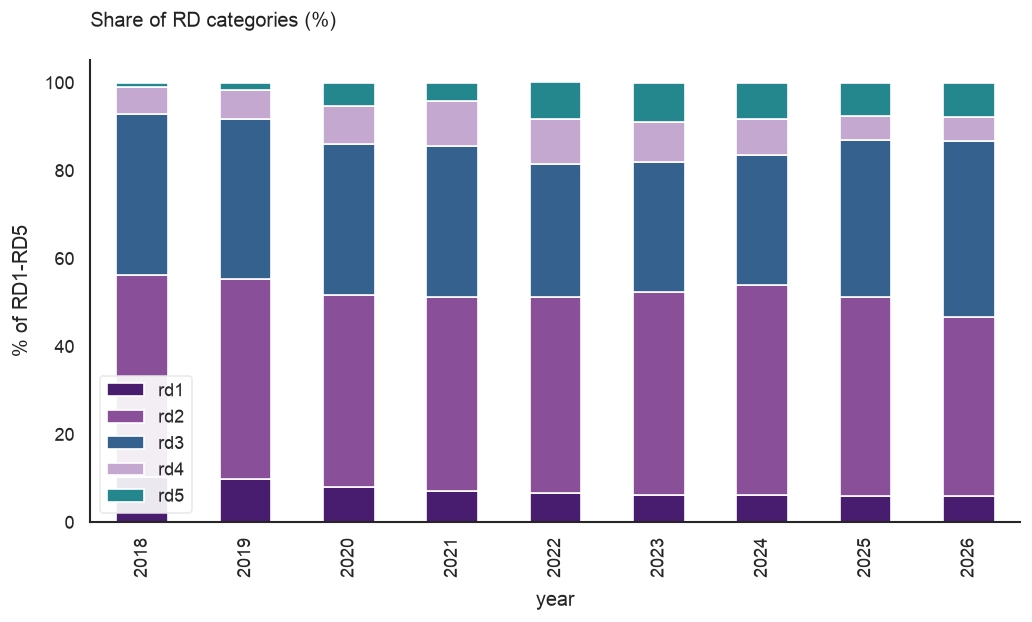

In [10]:
df_rd_share = (df_rd.set_index('year')[['rd1', 'rd2', 'rd3', 'rd4', 'rd5']].pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)).round(1)
show_df(df_rd_share.reset_index())
ax = df_rd_share.plot(kind='bar', stacked=True, figsize=(10, 5), title='Share of RD categories (%)')
ax.set_ylabel('% of RD1-RD5')

### Critical vs Cumulative RD Levels

Welche Kombination aus RD1 bis RD5 entspricht `mission_count_ems_critical` in welchem Jahr? Verhältnis in Prozent (100 = gleich).

In [11]:
df_cum = df_rd[['year', 'critical']].copy()
cum = df_rd['rd1'].copy()
for k in range(1, 6):
    if k > 1:
        cum = cum + df_rd[f'rd{k}']
    df_cum[f'vs_rd1_to_rd{k}_pct'] = (df_rd['critical'] / cum * 100).round(0)
show_df(df_cum)

,year,critical,vs_rd1_to_rd1_pct,vs_rd1_to_rd2_pct,vs_rd1_to_rd3_pct,vs_rd1_to_rd4_pct,vs_rd1_to_rd5_pct
0,2018,371883.00,1391.00%,254.00%,153.00%,144.00%,142.00%
1,2019,379973.00,1410.00%,253.00%,153.00%,143.00%,140.00%
2,2020,347567.00,1515.00%,231.00%,139.00%,126.00%,119.00%
3,2021,372495.00,1540.00%,210.00%,126.00%,113.00%,108.00%
4,2022,431395.00,1487.00%,190.00%,120.00%,106.00%,97.00%
5,2023,434200.00,1529.00%,181.00%,116.00%,104.00%,95.00%
6,2024,459475.00,1540.00%,177.00%,114.00%,104.00%,95.00%
7,2025,330364.00,1032.00%,119.00%,70.00%,66.00%,61.00%
8,2026,205861.00,818.00%,105.00%,57.00%,53.00%,49.00%


### The Break on 25 March 2025

Die BF dokumentiert auf ihrer Open-Data-Seite, dass sie seit dem **25.03.2025** Notfallkategorien zur Klassifikation und Beschickung nutzt; die Zahlen davor wurden aus den Dispatchcodes berechnet. Wie sieht der Anteil "kritischer" Einsätze um dieses Datum aus?

In [12]:
df_break = q("""
    select mission_date, mission_count_ems, mission_count_ems_critical, round(100.0 * mission_count_ems_critical / mission_count_ems, 1) as critical_pct_of_ems,
           mission_count_rd1 + mission_count_rd2 as rd1_rd2, round(100.0 * (mission_count_rd1 + mission_count_rd2) / mission_count_ems, 1) as rd1_rd2_pct_of_ems
    from stg_daily_missions where mission_date between '2025-03-21' and '2025-03-29' order by 1
""")
show_df(df_break)

,mission_date,mission_count_ems,mission_count_ems_critical,critical_pct_of_ems,rd1_rd2,rd1_rd2_pct_of_ems
0,2025-03-21 00:00:00,1465,1412,96.40%,829,56.60%
1,2025-03-22 00:00:00,1385,1334,96.30%,766,55.30%
2,2025-03-23 00:00:00,1291,1239,96.00%,713,55.20%
3,2025-03-24 00:00:00,1419,1367,96.30%,814,57.40%
4,2025-03-25 00:00:00,1321,913,69.10%,751,56.90%
5,2025-03-26 00:00:00,1364,859,63.00%,849,62.20%
6,2025-03-27 00:00:00,1336,836,62.60%,825,61.80%
7,2025-03-28 00:00:00,1410,850,60.30%,842,59.70%
8,2025-03-29 00:00:00,1392,869,62.40%,852,61.20%


,month,critical_pct_of_ems,rd1_rd2_pct_of_ems
0,2024-01-01 00:00:00,94.50%,53.30%
3,2024-04-01 00:00:00,95.10%,53.80%
6,2024-07-01 00:00:00,95.70%,53.10%
9,2024-10-01 00:00:00,95.60%,54.50%
12,2025-01-01 00:00:00,95.60%,57.90%
15,2025-04-01 00:00:00,61.00%,60.20%
18,2025-07-01 00:00:00,54.90%,52.60%
21,2025-10-01 00:00:00,56.80%,54.30%
24,2026-01-01 00:00:00,55.00%,52.40%
27,2026-04-01 00:00:00,54.00%,51.80%


Text(0, 0.5, '% of EMS missions')

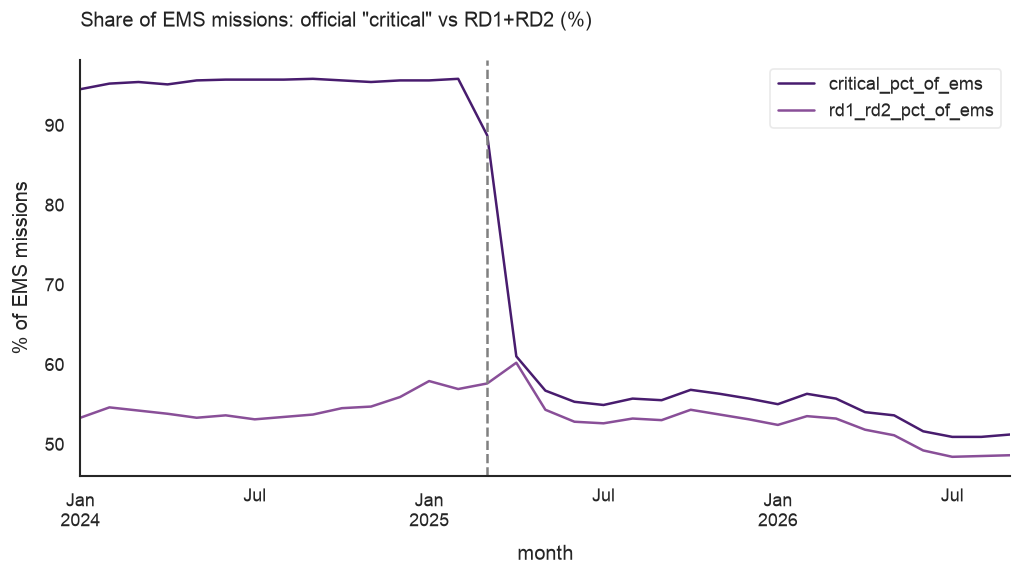

In [13]:
df_break_m = q("""
    select date_trunc('month', mission_date)::date as month,
           round(100.0 * sum(mission_count_ems_critical) / sum(mission_count_ems), 1) as critical_pct_of_ems,
           round(100.0 * sum(mission_count_rd1 + mission_count_rd2) / sum(mission_count_ems), 1) as rd1_rd2_pct_of_ems
    from stg_daily_missions where mission_date between '2024-01-01' and '2026-09-30' group by 1 order by 1
""")
show_df(df_break_m.iloc[::3])
ax = df_break_m.set_index('month').plot(figsize=(10, 4.5), title='Share of EMS missions: official "critical" vs RD1+RD2 (%)')
ax.axvline(pd.Timestamp('2025-03-25'), color='grey', linestyle='--'); ax.set_ylabel('% of EMS missions')

Der Anteil "kritisch" fällt an genau diesem Tag sprunghaft; RD1 plus RD2 bleibt dagegen über den Stichtag hinweg bei etwa der Hälfte der Rettungsdiensteinsätze. **RD1+RD2 ist damit die vergleichbare Gruppe über die ganze Zeitreihe.**

### Approximating RD1+RD2 from the Missions

Die Einzeleinsätze tragen nur Kategorie und Stufe (A bis E, O) des Notrufsystems, nicht die Notfallkategorie. Welche Näherung kommt der offiziellen RD1+RD2-Menge (Tagesreihe) am nächsten? Verglichen: die Stufen D/E, die Stufen C/D/E und eine Schätzung aus der BF-Codetabelle (`seed_dispatch_code_map`, Anteil RD1/RD2 je Kategorie und Stufe, ungewichtet nach Einsatzzahl).

In [14]:
df_calib = q("""
    with m as (
        select m.source_year as year,
               count(*) filter (where m.dispatch_criticality in ('D', 'E')) as lvl_de,
               count(*) filter (where m.dispatch_criticality in ('C', 'D', 'E')) as lvl_cde,
               sum(cast(x.share_rd1_rd2 as double)) as code_prior,
               count(*) filter (where x.dispatchcode is null) as unmapped
        from int_missions_enriched m
        left join seed_dispatch_code_map x on x.dispatchcode = m.dispatchcode and x.dispatch_level = m.dispatch_criticality
        where m.mission_group = 'ems' group by 1),
         d as (select year(mission_date) as year, sum(mission_count_rd1 + mission_count_rd2) as official_rd1_rd2 from stg_daily_missions group by 1)
    select year, official_rd1_rd2, lvl_de, round(100.0 * lvl_de / official_rd1_rd2 - 100, 1) as de_vs_official_pct,
           lvl_cde, round(100.0 * lvl_cde / official_rd1_rd2 - 100, 1) as cde_vs_official_pct,
           round(code_prior, 0) as code_prior, round(100.0 * code_prior / official_rd1_rd2 - 100, 1) as prior_vs_official_pct, unmapped
    from m join d using (year) order by year
""")
show_df(df_calib)

,year,official_rd1_rd2,lvl_de,de_vs_official_pct,lvl_cde,cde_vs_official_pct,code_prior,prior_vs_official_pct,unmapped
0,2018,146623.00,72177,-50.80%,160042,9.20%,118906.00,-18.90%,99282
1,2019,150309.00,74567,-50.40%,167531,11.50%,121956.00,-18.90%,94033
2,2020,150390.00,85460,-43.20%,185829,23.60%,124740.00,-17.10%,87620
3,2021,177421.00,99831,-43.70%,218976,23.40%,148683.00,-16.20%,52981
4,2022,227012.00,107767,-52.50%,248850,9.60%,184732.00,-18.60%,32270
5,2023,239598.00,110251,-54.00%,262862,9.70%,183511.00,-23.40%,30476
6,2024,259995.00,124054,-52.30%,283460,9.00%,199466.00,-23.30%,24340
7,2025,276476.00,130973,-52.60%,298655,8.00%,216931.00,-21.50%,14490
8,2026,196127.00,106832,-45.50%,238268,21.50%,172792.00,-11.90%,11419


Die Stufen D/E sind viel zu eng (rund die Hälfte der offiziellen Menge). C/D/E überschätzt die offizielle Menge, liegt ihr aber am nächsten; die Code-Schätzung unterschätzt sie, auch weil sie die Einsatzzahl je Code nicht kennt.

## Response Time Statistics

Die Tagesstatistik betrifft nur *kritische* Rettungsdiensteinsätze sowie Brand- und technische Einsätze. Ein Jahreswert ist hier der Mittelwert der Tagesmediane, kein Jahresmedian.

,year,ems_critical_s,ems_critical_cpr_s,fire_first_pump_s,technical_rescue_s
0,2018,573.00,504.00,592.00,760.00
1,2019,565.00,497.00,594.00,746.00
2,2020,581.00,504.00,585.00,778.00
3,2021,593.00,497.00,595.00,813.00
4,2022,622.00,506.00,595.00,809.00
5,2023,611.00,498.00,588.00,815.00
6,2024,614.00,490.00,595.00,798.00
7,2025,584.00,478.00,577.00,775.00
8,2026,574.00,472.00,567.00,796.00


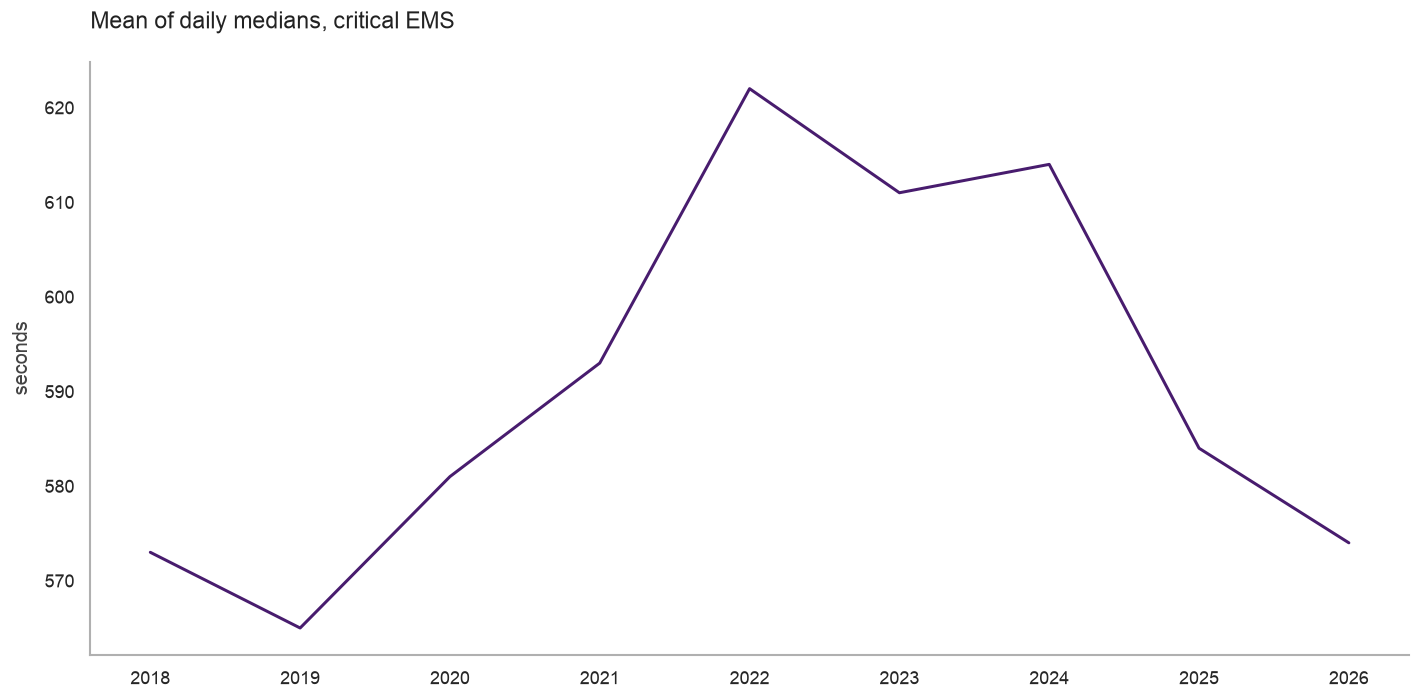

In [15]:
df_rt = q("""
    select year(mission_date) as year,
           round(avg(response_time_ems_critical_median), 0) as ems_critical_s,
           round(avg(response_time_ems_critical_cpr_median), 0) as ems_critical_cpr_s,
           round(avg(response_time_fire_time_to_first_pump_median), 0) as fire_first_pump_s,
           round(avg(response_time_technical_rescue_median), 0) as technical_rescue_s
    from stg_daily_missions group by 1 order by 1
""")
show_df(df_rt)
fig, ax = line(df_rt, x='year', y='ems_critical_s', title='Mean of daily medians, critical EMS', ylabel='seconds')

## Special Days

In [16]:
df_top = q("""
    select mission_date, dayname(mission_date) as weekday, mission_count_all, mission_count_ems_critical,
           round(response_time_ems_critical_median, 0) as median_s
    from stg_daily_missions order by mission_count_all desc limit 10
""")
show_df(df_top)

,mission_date,weekday,mission_count_all,mission_count_ems_critical,median_s
0,2022-02-19 00:00:00,Saturday,2716,971,624.00
1,2022-02-17 00:00:00,Thursday,2497,1046,603.00
2,2026-01-01 00:00:00,Thursday,2440,1043,572.00
3,2023-01-01 00:00:00,Sunday,2431,1660,601.00
4,2025-06-23 00:00:00,Monday,2391,869,595.00
5,2025-01-01 00:00:00,Wednesday,2385,1536,592.00
6,2024-01-01 00:00:00,Monday,2338,1607,601.00
7,2025-06-26 00:00:00,Thursday,2318,792,592.00
8,2025-12-27 00:00:00,Saturday,2259,897,641.00
9,2018-01-01 00:00:00,Monday,2229,1019,560.00


In [17]:
df_nye = q("""
    select mission_date, mission_count_all, mission_count_ems_critical, round(response_time_ems_critical_median, 0) as median_s
    from stg_daily_missions
    where (month(mission_date) = 12 and day(mission_date) = 31) or (month(mission_date) = 1 and day(mission_date) = 1)
    order by mission_date
""")
show_df(df_nye)

,mission_date,mission_count_all,mission_count_ems_critical,median_s
0,2018-01-01 00:00:00,2229,1019,560.00
1,2018-12-31 00:00:00,1352,766,534.00
2,2019-01-01 00:00:00,2057,999,538.00
3,2019-12-31 00:00:00,1400,724,539.00
4,2020-01-01 00:00:00,2176,1089,566.00
5,2020-12-31 00:00:00,1189,670,557.00
6,2021-01-01 00:00:00,1593,870,581.00
7,2021-12-31 00:00:00,1388,1038,558.00
8,2022-01-01 00:00:00,1855,1372,577.00
9,2022-12-31 00:00:00,1742,1238,578.00


In [18]:
df_covid = q("""
    select date_trunc('month', mission_date)::date as month, round(avg(mission_count_all), 0) as avg_missions_per_day
    from stg_daily_missions where mission_date between '2019-09-01' and '2021-06-30' group by 1 order by 1
""")
show_df(df_covid)

,month,avg_missions_per_day
0,2019-09-01 00:00:00,1266.00
1,2019-10-01 00:00:00,1267.00
2,2019-11-01 00:00:00,1306.00
3,2019-12-01 00:00:00,1295.00
4,2020-01-01 00:00:00,1318.00
5,2020-02-01 00:00:00,1315.00
6,2020-03-01 00:00:00,1275.00
7,2020-04-01 00:00:00,1144.00
8,2020-05-01 00:00:00,1191.00
9,2020-06-01 00:00:00,1312.00


## Reconciliation with Mission Data

Die Tagesreihe ist eine offizielle Aggregation. Passen ihre Zahlen zu den Einzeleinsätzen, die wir selbst auswerten?

In [19]:
df_rec = q("""
    with m as (select source_year as year, count(*) as missions_detail,
                      count(*) filter (where mission_type like 'Rettungsdienst%') as ems_detail,
                      count(*) filter (where mission_type = 'Brand') as fire_detail
               from stg_missions group by 1),
         d as (select year(mission_date) as year, sum(mission_count_all) as missions_daily, sum(mission_count_ems) as ems_daily,
                      sum(mission_count_fire) as fire_daily from stg_daily_missions group by 1)
    select year, missions_daily, missions_detail, round(100.0 * (missions_daily - missions_detail) / missions_detail, 2) as all_diff_pct,
           ems_daily, ems_detail, round(100.0 * (ems_daily - ems_detail) / ems_detail, 2) as ems_diff_pct,
           fire_daily, fire_detail
    from d join m using (year) order by year
""")
show_df(df_rec)

,year,missions_daily,missions_detail,all_diff_pct,ems_daily,ems_detail,ems_diff_pct,fire_daily,fire_detail
0,2018,465755.00,463684,0.45%,433303.00,431302,0.46%,15055.00,15027
1,2019,474736.00,472638,0.44%,433504.00,431777,0.40%,15861.00,15852
2,2020,468682.00,466774,0.41%,418403.00,417175,0.29%,15878.00,15867
3,2021,492231.00,489860,0.48%,440587.00,438871,0.39%,16405.00,16397
4,2022,528921.00,526743,0.41%,473888.00,472289,0.34%,18714.00,18710
5,2023,514830.00,512885,0.38%,462936.00,461555,0.30%,18827.00,18822
6,2024,534452.00,532575,0.35%,481462.00,480087,0.29%,20652.00,20645
7,2025,558721.00,556864,0.33%,503371.00,501943,0.28%,21630.00,21623
8,2026,429119.00,439179,-2.29%,386933.00,396217,-2.34%,17082.00,17556


In [20]:
df_rec_day = q("""
    with m as (select mission_date, count(*) as n from stg_missions group by 1)
    select d.mission_date, d.mission_count_all as daily, m.n as detail, d.mission_count_all - m.n as diff,
           round(100.0 * (d.mission_count_all - m.n) / m.n, 1) as diff_pct
    from stg_daily_missions d join m using (mission_date)
    order by abs(d.mission_count_all - m.n) desc limit 10
""")
show_df(df_rec_day)
df_rec_share = q("""
    with m as (select mission_date, count(*) as n from stg_missions group by 1)
    select count(*) as days,
           count(*) filter (where abs(d.mission_count_all - m.n) > 0.02 * m.n) as days_over_2pct,
           count(*) filter (where d.mission_count_all < m.n) as days_daily_lower,
           count(*) filter (where d.mission_count_all > m.n) as days_daily_higher
    from stg_daily_missions d join m using (mission_date)
""")
show_df(df_rec_share)

,mission_date,daily,detail,diff,diff_pct
0,2021-09-02 00:00:00,1506,1489,17,1.10%
1,2022-06-25 00:00:00,1633,1617,16,1.00%
2,2025-10-13 00:00:00,1558,1543,15,1.00%
3,2018-03-15 00:00:00,1403,1388,15,1.10%
4,2021-12-02 00:00:00,1441,1426,15,1.10%
5,2021-11-24 00:00:00,1479,1464,15,1.00%
6,2021-11-26 00:00:00,1449,1434,15,1.00%
7,2018-02-24 00:00:00,1305,1290,15,1.20%
8,2019-06-07 00:00:00,1501,1486,15,1.00%
9,2021-11-20 00:00:00,1389,1375,14,1.00%


,days,days_over_2pct,days_daily_lower,days_daily_higher
0,3195,0,0,3156


## Findings

### Content

Stadtweite Tagesreihe der Berliner Feuerwehr ab 2018-01-01: Einsatzzahlen nach Art (gesamt, Rettungsdienst, kritischer Rettungsdienst, Reanimation, Brand, technische Hilfe), Zahlen je Rettungsdienst-Notfallkategorie RD1 bis RD5 und Statistik der Antwortzeiten (Mittelwert, Median, Standardabweichung) für kritischen Rettungsdienst, Reanimation, Brand (bis erstes Löschfahrzeug, erste Drehleiter, 14 Einsatzkräfte) und technische Hilfe. Die Tagesreihe enthält keine Hilfsfrist-Spalten.

### Usefulness

* **Gegenprobe** zu den Einzeleinsätzen: Die Summen passen auf wenige Promille.
* **Tagesgenaue Sonderereignisse** (Jahreswechsel, Stürme, Pandemiewellen).
* **Belegt die Definitionsänderung von "kritisch"** auf den Tag genau und liefert mit RD1+RD2 eine über die ganze Reihe vergleichbare Gruppe.
* **Nach Einsatzart getrennt:** Rettungsdienst, Brand und technische Hilfe haben eigene Zeit-Kennzahlen, wie auf der Open-Data-Seite der BF.

### Limits

* **Nur stadtweit**, keine Bezirke, keine Regionen, keine Hilfsfrist-Spalten.
* **Lücken:** Im Stand dieser Ausführung fehlen sieben Tage, alle 2026. An diesen Tagen enthalten die Einzeleinsätze zwischen 1.500 und 1.800 Einsätze je Tag.
* **Statistik nur für Teilmengen** (kritischer Rettungsdienst, Reanimation, Brand, technische Hilfe). Ein Jahreswert ist hier der Mittelwert der Tagesmediane bzw. der gewichtete Mittelwert der Tagesmittel, kein echter Jahresmedian.
* **"Kritisch" ist nicht stabil:** Seit dem 25.03.2025 gelten Notfallkategorien; die Zahl "kritischer" Einsätze bricht an diesem Tag ein. Vergleiche der Reihe `mission_count_ems_critical` über diese Grenze sind nicht zulässig.
* **RD-Kategorien vor dem Stichtag** hat die BF aus den Dispatchcodes berechnet, danach nutzt sie die Kategorien zur Disposition. In den frühen Jahren decken sie nur einen Teil der Rettungsdiensteinsätze ab.

### Observations

Stand der Ausführung, Daten bis 2026-10-07. Zusammenhänge, keine Ursachen.

| Beobachtung | Beleg im Notebook |
|---|---|
| Die Tagesreihe liegt an jedem Tag gleich oder knapp über der Summe der Einzeleinsätze (bis 1,2 %), jährlich um rund 0,3 bis 0,5 %. Nirgends darunter | Reconciliation with Mission Data |
| Die Abweichung 2026 (Reihe unter den Einzeleinsätzen) kommt von den sieben fehlenden Tagen. BACKLOG 10 ist damit im Kern geklärt | Missing Days, Reconciliation |
| **Der Anteil "kritisch" fällt am 25.03.2025 von rund 96 % auf rund 69 % der Rettungsdiensteinsätze und liegt danach bei rund 60 %.** Das ist der von der BF dokumentierte Stichtag der Notfallkategorien | The Break on 25 March 2025 |
| **RD1 plus RD2 bleibt über den Stichtag hinweg bei rund der Hälfte der Rettungsdiensteinsätze** und ist die über die Zeit vergleichbare "kritisch"-Gruppe | The Break on 25 March 2025 |
| Näherung aus den Einzeleinsätzen: Die Stufen D/E erfassen nur rund die Hälfte der offiziellen RD1+RD2-Menge, C/D/E überschätzt sie um etwa ein Zehntel bis ein Viertel, die Schätzung aus der Code-Tabelle unterschätzt um rund ein Fünftel | Approximating RD1+RD2 from the Missions |
| In den frühen Jahren decken RD1 bis RD5 nur einen Teil der Rettungsdiensteinsätze ab (2018 rund 60 %), ab 2023/2024 praktisch alle | RD1 to RD5 |
| Verteilung der RD-Kategorien verschiebt sich 2025/2026 (RD3 steigt, RD2 und RD4 sinken). Vermutung: neue medizinische Codezuordnung (Dateien im Upstream-Ordner `Dispatchcodes` mit Datum 2025-11 und 2026-05) | Share of RD categories |
| Einsätze pro Tag steigen von rund 1.280 (2018) auf rund 1.530 (2025) und 1.570 (2026) | Per Year |
| Saison schwach: Juni am höchsten, April am niedrigsten; Antwortzeiten im Dezember am längsten. Wochentag: Montag am meisten Einsätze, Sonntag am wenigsten und am schnellsten | Seasonality and Weekday |
| Pandemie: Einbruch im April/Mai 2020 und im Winter 2021 gegenüber den Vormonaten | Special Days |
| Fünf der zehn Spitzentage sind ein 1. Januar. Die Spitzen im Februar 2022 und am 23. Juni 2025 fallen auf Sturmlagen (BF-Diagramm: Ylenia und Zeynep, Ziros); der zweite Spitzentag am 26.06.2025 ist nicht erklärt. Jahreswechsel 2024/25 zeigt in den Einsatzzahlen nichts Auffälliges | Special Days |
| Antwortzeit kritischer Einsätze (Mittel der Tagesmediane) steigt bis 2022, fällt danach und liegt 2026 nahe dem Niveau von 2018. Das Muster überlagert zwei Strukturänderungen (RTW-B ab Januar 2023, Notfallkategorien 25.03.2025) | Response Time Statistics |

### Open Questions

* **`02_preparation`:** Die sieben fehlenden Tage nicht auffüllen, aber dokumentieren; Test auf Lücken in der Zeitreihe (dbt-Test); `mission_group`-Zuordnung und RD1+RD2 als Vergleichsgruppe festhalten.
* **`03_analysis_time` und `_mission_type`:** Antwortzeit-Trend innerhalb stabiler Gruppen vergleichen (RD1+RD2 über die Daily-Reihe, C/D/E als Näherung in den Einzeleinsätzen) und die zwei Strukturänderungen als Brüche modellieren.
* **`03_analysis_special_events`:** Zweiten Spitzentag 26.06.2025 prüfen, Stürme und Pandemie getrennt ausweisen.
* **BACKLOG 1:** Die BF bestätigt den Stichtag; offen bleibt, ob "kritisch" vor dem 25.03.2025 nach der Dispatch-Stufe lief (Hinweis: ja, die BF schreibt, die Zahlen davor seien aus den Dispatchcodes berechnet).